# Introduction
This Colab worksheet provides a starting point for Task 1 (the natural language processing task).

# Data Loading

In [ ]:
# Download the data stored in a csv file
# If you're running all your experiments on a machine at home rather than using colab, then make sure you save it rather than repeatedly downloading it.

# training data
!wget "https://sussex.box.com/shared/static/xjewvhv527xq083j8ehtsjcijs1i4kra.csv" -O sentiment_analysis_training_data.csv
# validation data
!wget "https://sussex.box.com/shared/static/qv30jx3xfwer1va1k19nhndq2xaso67x.csv" -O sentiment_analysis_validation_data.csv
# test data (without labels)
!wget "https://sussex.box.com/shared/static/zu44986583mlocifzyx6dsmqe20g1hlh.csv" -O sentiment_analysis_test_data.csv

--2026-05-22 19:01:17--  https://sussex.box.com/shared/static/xjewvhv527xq083j8ehtsjcijs1i4kra.csv
Resolving sussex.box.com (sussex.box.com)... 74.112.186.157, 2620:117:bff0:12d::
Connecting to sussex.box.com (sussex.box.com)|74.112.186.157|:443... connected.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: /public/static/xjewvhv527xq083j8ehtsjcijs1i4kra.csv [following]
--2026-05-22 19:01:17--  https://sussex.box.com/public/static/xjewvhv527xq083j8ehtsjcijs1i4kra.csv
Reusing existing connection to sussex.box.com:443.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: https://sussex.app.box.com/public/static/xjewvhv527xq083j8ehtsjcijs1i4kra.csv [following]
--2026-05-22 19:01:17--  https://sussex.app.box.com/public/static/xjewvhv527xq083j8ehtsjcijs1i4kra.csv
Resolving sussex.app.box.com (sussex.app.box.com)... 74.112.186.157, 2620:117:bff0:12d::
Connecting to sussex.app.box.com (sussex.app.box.com)|74.112.186.157|:443... connected.
HTTP request

# Load the data

In [ ]:
import pandas as pd

# load the training data using np.load
# repeat this for validation and test data, but note the latter has no labels
data_train = pd.read_csv('sentiment_analysis_training_data.csv')

# extract the text
text_train = data_train['text'].values
# and the labels
labels_train = data_train['label'].values
print(data_train.shape, text_train.shape, labels_train.shape)

data_val = pd.read_csv('sentiment_analysis_validation_data.csv')
# extract the text
text_val = data_val['text'].values
# and the labels
labels_val = data_val['label'].values
print(data_val.shape, text_val.shape, labels_val.shape)

data_test = pd.read_csv('sentiment_analysis_test_data.csv')
# extract the text
text_test = data_test['text'].values
print(data_test.shape, text_test.shape)

(11503, 2) (11503,) (11503,)
(1397, 2) (1397,) (1397,)
(1434, 1) (1434,)


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
import warnings

warnings.filterwarnings('ignore')

# TASK 1 BASELINE: TF-IDF + Logistic Regression (30 minutes to working metrics)

# Imports + Convert to DataFrames
# Convert the numpy arrays from the worksheet into DataFrames
# This makes EDA abd manipulation easier to execute

train_df = pd.DataFrame({'text': text_train,
                         'label': labels_train}) # from the worksheet provided

val_df = pd.DataFrame({'text': text_val,
                       'label': labels_val})

test_df = pd.DataFrame({'text': text_test})


print("Data has successfully converted to DataFrames")
print(f"Train shape: {train_df.shape}")
print(f"Validation shape: {val_df.shape}")
print(f"Test shape: {test_df.shape}")

print("\nClass distribution in training set:")
print(train_df['label'].value_counts(normalize=True))

print("\nClass distribution in validation set:")
print(val_df['label'].value_counts(normalize=True))



Data has successfully converted to DataFrames
Train shape: (11503, 2)
Validation shape: (1397, 2)
Test shape: (1434, 1)

Class distribution in training set:
label
1    0.501347
0    0.498653
Name: proportion, dtype: float64

Class distribution in validation set:
label
1    0.503937
0    0.496063
Name: proportion, dtype: float64


Likely spam in training set: 2973 / 11503 (25.8%)


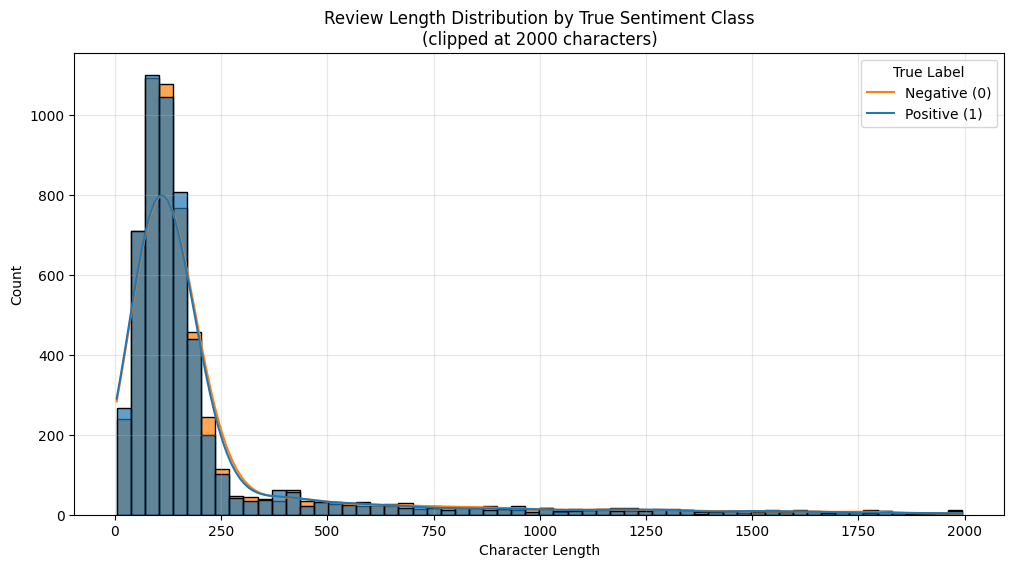


*** Possible Spam / Junk Examples (by keyword) ***
                                                 text  label  is_likely_spam
3   Subject: valero\r\neach meter is now to be tre...      0            True
41  Subject: global octanes\r\nfinished visiting w...      1            True
50  this is not chabrol's best , but even his less...      1           False
74  moonlight mile gives itself the freedom to fee...      1           False
81  Subject: entex transistion\r\nthe purpose of t...      1            True
84  i admire the closing scenes of the film , whic...      1           False

*** Example Positive Review ***
a startling and fresh examination of how the bike still remains an ambiguous icon in chinese society .

*** Example Negative Review ***
Subject: 98 - 6736 & 98 - 9638 for 1997 ( ua 4 issues )
the above referenced meters need to be placed on a k . please note the
information below
98 - 6736 on 089 for 5 / 97 ( activity @ this meter for 1 / 97 - 4 / 97 is on
078 - 29165 - 101

In [ ]:
# EXPLORATORY DATA ANALYSIS (EDA) + Spam Discovery
# This fulfills STEP 1 and STEP 2 of the workflow
# =============================================================================

# Review length column
train_df['length'] = train_df['text'].str.len()

# Dataset-specific spam indicators (very effective for this assignment)
train_df['starts_with_subject'] = train_df['text'].str.lower().str.startswith('subject:')
train_df['has_line_breaks']     = train_df['text'].str.contains(r'\r\n|\n\n', na=False)
train_df['is_likely_spam']      = train_df['starts_with_subject'] | train_df['has_line_breaks']

print(f"Likely spam in training set: {train_df['is_likely_spam'].sum()} / {len(train_df)} "
      f"({train_df['is_likely_spam'].mean()*100:.1f}%)")

# Length distribution plot (needed for report Figure 1)
plt.figure(figsize=(12, 6))
sns.histplot(data=train_df[train_df['length'] < 2000],
             x='length', hue='label', bins=60, alpha=0.7, kde=True)
plt.title('Review Length Distribution by True Sentiment Class\n(clipped at 2000 characters)')
plt.xlabel('Character Length')
plt.ylabel('Count')
plt.legend(title='True Label', labels=['Negative (0)', 'Positive (1)'])
plt.grid(True, alpha=0.3)
plt.savefig('review_length_distribution.png', dpi=200, bbox_inches='tight')
plt.show()

# Additional spam keyword check
spam_keywords = r'free|offer|click|buy|winner|urgent|viagra|cialis|earn|cash|prize|discount'
train_df['contains_spam_keyword'] = train_df['text'].str.contains(spam_keywords, case=False, na=False)

print("\n*** Possible Spam / Junk Examples (by keyword) ***")
print(train_df[train_df['contains_spam_keyword']].head(6)[['text', 'label', 'is_likely_spam']])

# Example real reviews
print("\n*** Example Positive Review ***")
print(train_df[train_df['label'] == 1]['text'].iloc[0][:650])

print("\n*** Example Negative Review ***")
print(train_df[train_df['label'] == 0]['text'].iloc[0][:650])

# Bonus: Check for duplicates
print(f"\nDuplicate texts in training set: {train_df['text'].duplicated().sum()}")

In [ ]:
# TEXT PREPROCESSING
# Conservative approach to preserve sentiment cues (especially negation)

def preprocess_text(text):
    """
    Clean text while preserving sentiment-important elements and
    handling spam formatting.
    """
    text = str(text)

    # Fix email-style line breaks
    text = text.replace('\r\n', ' ').replace('\n\n', ' ').replace('\n', ' ')

    text = str(text).lower()                    # Lowercase


    # Replace common spam (noisy) elements with consistent tokens
    text = re.sub(r'http\S+|www\.\S+', ' url ', text)
    text = re.sub(r'\S+@\S+',          ' email ', text)
    text = re.sub(r'\d+',              ' num ',   text) # Replace numbers


    # Keep only letters and useful punctuation for sentiment
    text = re.sub(r'[^a-z\s\!\?\.\,]', ' ', text)

    # Clean whitespace
    text = re.sub(r'\s+', ' ', text).strip()

    return text

# Apply preprocessing to all datasets
train_df['clean_text'] = train_df['text'].apply(preprocess_text)
val_df['clean_text']   = val_df['text'].apply(preprocess_text)
test_df['clean_text']  = test_df['text'].apply(preprocess_text)

print(" *** Preprocessing completed on train, val, and test sets. *** ")
print("\nSample cleaned text/spam:")
print(train_df[train_df['is_likely_spam']]['clean_text'].iloc[0][:400])

print("\nSample cleaned real review:")
print(train_df[~train_df['is_likely_spam']]['clean_text'].iloc[0][:400])

 *** Preprocessing completed on train, val, and test sets. *** 

Sample cleaned text/spam:
subject num num num num for num ua num issues the above referenced meters need to be placed on a k . please note the information below num num on num for num num activity this meter for num num num num is on num num num the referenced cpr deal is num which ends num num . num num on num for num num activity this meter for num num num num is also on num no referenced cpr deal . the only month that h

Sample cleaned real review:
nearly every attempt at humor here is doa .


## Model overview

This notebook develops Task 1 in four stages:

- **Baseline:** a TF-IDF + Logistic Regression model trained on the original review text.
- **System 2:** a sentiment model trained on a cleaned version of the data after removing likely spam or junk reviews.
- **System 3a (rejected hybrid):** a spam-aware approach that combined heuristic spam rules with a low-confidence prediction filter. This version was explored but rejected because it marked too many validation reviews as spam.
- **System 3b (final rules-based):** the final spam-aware system, which keeps the heuristic spam rules but removes the overly aggressive confidence threshold. This is the version used to produce the final test predictions.

This structure shows how the work moved from a simple baseline to a more robust final system, with validation results used to guide each change.

In [ ]:
# FEATURE EXTRACTION: TF-IDF with n-grams + LOGISTIC REGRESSION BASELINE
# ======================================================================
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report



# TF-IDF Vectorizer (strong baseline with n-grams)
vectorizer = TfidfVectorizer(
    ngram_range=(1, 3),      # Important: captures phrases like "not good", "very bad"
    max_features=12000,
    min_df=2,                # Ignore very rare words
    max_df=0.9,              # Ignore very common words
    stop_words='english'
)

# Fit on training data only, transform all sets
X_train = vectorizer.fit_transform(train_df['clean_text'])
X_val   = vectorizer.transform(val_df['clean_text'])
X_test  = vectorizer.transform(test_df['clean_text'])

y_train = train_df['label'].values
y_val   = val_df['label'].values

print(f"TF-IDF vocabulary size: {len(vectorizer.vocabulary_)}")
print(f"Feature matrix shape: {X_train.shape}")

# *** BASELINE MODEL: Logistic Regression ***

model = LogisticRegression(
    C=2.0,                   # Regularization strength
    max_iter=1000,           # Convergence
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)

# Validation predictions
val_preds = model.predict(X_val)
val_probs = model.predict_proba(X_val)[:, 1]   # probability of positive class

print("\n" + "="*70)
print("BASELINE MODEL PERFORMANCE ON VALIDATION SET")
print("="*70)
print(f"Accuracy : {accuracy_score(y_val, val_preds):.4f}")
print(f"Macro F1 : {f1_score(y_val, val_preds, average='macro'):.4f}")
print("\nConfusion Matrix:")
print(confusion_matrix(y_val, val_preds))
print("\nClassification Report:")
print(classification_report(y_val, val_preds))

TF-IDF vocabulary size: 12000
Feature matrix shape: (11503, 12000)

BASELINE MODEL PERFORMANCE ON VALIDATION SET
Accuracy : 0.6736
Macro F1 : 0.6734

Confusion Matrix:
[[486 207]
 [249 455]]

Classification Report:
              precision    recall  f1-score   support

           0       0.66      0.70      0.68       693
           1       0.69      0.65      0.67       704

    accuracy                           0.67      1397
   macro avg       0.67      0.67      0.67      1397
weighted avg       0.67      0.67      0.67      1397



In [ ]:
# SYSTEM 2: CLEAN-ONLY MODEL (Train on non-spam samples only - Main Version)
# =============================================================================
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report

# Filter clean training data
train_clean = train_df[~train_df['is_likely_spam']].copy()
print("Clean training shape:", train_clean.shape)
print("Class distribution in clean training:", train_clean['label'].value_counts(normalize=True))

# Fit a NEW vectorizer ONLY on clean training data
vectorizer_clean = TfidfVectorizer(
    ngram_range=(1, 3),
    max_features=12000,
    min_df=2,
    max_df=0.9,
    stop_words='english'
)

X_train_clean = vectorizer_clean.fit_transform(train_clean['clean_text'])
X_val = vectorizer_clean.transform(val_df['clean_text'])   # full validation (realistic)

y_train_clean = train_clean['label'].values
y_val = val_df['label'].values

# Train model
model_clean = LogisticRegression(C=2.0, max_iter=1000, random_state=42, n_jobs=-1)
model_clean.fit(X_train_clean, y_train_clean)

# Evaluate on full validation set
val_preds_clean = model_clean.predict(X_val)

print("\n" + "="*75)
print("SYSTEM 2: CLEAN-ONLY MODEL (Vectorizer fitted on clean data only)")
print("="*75)
print(f"Accuracy on full validation : {accuracy_score(y_val, val_preds_clean):.4f}")
print(f"Macro F1 : {f1_score(y_val, val_preds_clean, average='macro'):.4f}")
print("\nConfusion Matrix:")
print(confusion_matrix(y_val, val_preds_clean))
print("\nClassification Report:")
print(classification_report(y_val, val_preds_clean))

Clean training shape: (8530, 8)
Class distribution in clean training: label
0    0.5
1    0.5
Name: proportion, dtype: float64

SYSTEM 2: CLEAN-ONLY MODEL (Vectorizer fitted on clean data only)
Accuracy on full validation : 0.6893
Macro F1 : 0.6867

Confusion Matrix:
[[545 148]
 [286 418]]

Classification Report:
              precision    recall  f1-score   support

           0       0.66      0.79      0.72       693
           1       0.74      0.59      0.66       704

    accuracy                           0.69      1397
   macro avg       0.70      0.69      0.69      1397
weighted avg       0.70      0.69      0.69      1397



In [ ]:
# Define System 2 misclassification sets for qualitative analysis
false_neg = val_df[(y_val == 1) & (val_preds_clean == 0)].copy()
false_pos = val_df[(y_val == 0) & (val_preds_clean == 1)].copy()

print(f"False negatives: {len(false_neg)}")
print(f"False positives: {len(false_pos)}")

False negatives: 286
False positives: 148


In [ ]:
# FAILURE CASE EXTRACTION — Medium-length examples for Report
# =============================================================================

# Ensure text length column exists
false_neg['text_len'] = false_neg['text'].astype(str).str.len()
false_pos['text_len'] = false_pos['text'].astype(str).str.len()

# Filter to medium-length reviews (80-350 characters) — these are usually
# the most useful for qualitative analysis (not too short, not too long)
false_neg_mid = false_neg[(false_neg['text_len'] >= 80) & (false_neg['text_len'] <= 350)]
false_pos_mid = false_pos[(false_pos['text_len'] >= 80) & (false_pos['text_len'] <= 350)]

print(f"Medium-length False Negatives found: {len(false_neg_mid)}")
print(f"Medium-length False Positives found: {len(false_pos_mid)}\n")


# ====================== FALSE NEGATIVES ======================
print("=== FALSE NEGATIVES (Positive → Predicted Negative) ===")
for i, row in false_neg_mid.head(12).iterrows():
    print(f"Index {i} | Length: {row['text_len']}")
    print(row['text'][:450].replace('\n', ' '))
    print("-" * 70)

print("\n=== FALSE POSITIVES (Negative → Predicted Positive) ===")
for i, row in false_pos_mid.head(12).iterrows():
    print(f"Index {i} | Length: {row['text_len']}")
    print(row['text'][:450].replace('\n', ' '))
    print("-" * 70)

Medium-length False Negatives found: 158
Medium-length False Positives found: 100

=== FALSE NEGATIVES (Positive → Predicted Negative) ===
Index 14 | Length: 134
 ls hpl lsk ic 25 . 000 / enron
----------------------------------------------------------------------
Index 20 | Length: 115
the real star of this movie is the score , as in the songs translate well to film , and it's really well directed .
----------------------------------------------------------------------
Index 30 | Length: 101
baby-faced renner is eerily convincing as this bland blank of a man with unimaginable demons within .
----------------------------------------------------------------------
Index 47 | Length: 103
grant is certainly amusing , but the very hollowness of the character he plays keeps him at arms length
----------------------------------------------------------------------
Index 61 | Length: 168
the messy emotions raging throughout this three-hour effort are instantly recognizable , allowing the film t

## System 3 development

System 3 was tested in two versions before the final submission was produced.

### System 3a: Rejected Hybrid variant
This version combined heuristic spam rules with an additional low-confidence sentiment threshold. Although the idea was reasonable, in practice, it identified too many validation examples as spam, so it was not kept as the final approach.

### System 3b: Final rules-based variant
This final version uses the heuristic spam rules on their own, together with the sentiment classifier trained on cleaned data. It gave a more reasonable spam rate on validation and was therefore used to generate the submission file.

In [ ]:
# SYSTEM 3: SPAM-AWARE HYBRID SYSTEM
# =============================================================================
import numpy as np
from sklearn.metrics import accuracy_score, f1_score

# Create spam flags for validation and test if not already present
val_df['starts_with_subject'] = val_df['text'].str.lower().str.startswith('subject:')
val_df['has_line_breaks'] = val_df['text'].str.contains(r'\r\n|\n\n', na=False)
val_df['is_likely_spam'] = val_df['starts_with_subject'] | val_df['has_line_breaks']

test_df['starts_with_subject'] = test_df['text'].str.lower().str.startswith('subject:')
test_df['has_line_breaks'] = test_df['text'].str.contains(r'\r\n|\n\n', na=False)
test_df['is_likely_spam'] = test_df['starts_with_subject'] | test_df['has_line_breaks']

# Use baseline model + baseline feature space
val_probs = model.predict_proba(X_val)[:, 1]
val_max_prob = np.maximum(val_probs, 1 - val_probs)

confidence_threshold = 0.68

# Hybrid spam detection: rules + low confidence
val_df['is_spam'] = val_df['is_likely_spam'] | (val_max_prob < confidence_threshold)

# Sentiment predictions
val_preds_sys3 = model.predict(X_val)
val_preds_sys3 = np.where(val_df['is_spam'], -1, val_preds_sys3)

# Evaluate only on samples not flagged as spam
clean_mask = ~val_df['is_spam']
print("\n" + "="*75)
print("SYSTEM 3: SPAM-AWARE HYBRID SYSTEM")
print("="*75)
print(f"Spam flagged in validation: {val_df['is_spam'].sum()} / {len(val_df)} "
      f"({val_df['is_spam'].mean()*100:.1f}%)")
print(f"Accuracy on non-spam validation samples: {accuracy_score(val_df.loc[clean_mask, 'label'], val_preds_sys3[clean_mask]):.4f}")
print(f"Macro F1 on non-spam validation samples: {f1_score(val_df.loc[clean_mask, 'label'], val_preds_sys3[clean_mask], average='macro'):.4f}")

# Test predictions
test_probs = model.predict_proba(X_test)[:, 1]
test_max_prob = np.maximum(test_probs, 1 - test_probs)
test_df['is_spam'] = test_df['is_likely_spam'] | (test_max_prob < confidence_threshold)

final_test_preds = model.predict(X_test)
final_test_preds = np.where(test_df['is_spam'], -1, final_test_preds)

print(f"\nTest spam flagged: {test_df['is_spam'].sum()} / {len(test_df)}")
print("Final prediction counts:")
print(pd.Series(final_test_preds).value_counts().sort_index())


SYSTEM 3: SPAM-AWARE HYBRID SYSTEM
Spam flagged in validation: 1228 / 1397 (87.9%)
Accuracy on non-spam validation samples: 0.5030
Macro F1 on non-spam validation samples: 0.4650

Test spam flagged: 803 / 1434
Final prediction counts:
-1    803
 0    302
 1    329
Name: count, dtype: int64


In [ ]:
# Second Attempt - SYSTEM 3: Tuned Spam-Aware System
# =============================================================================
import numpy as np
from sklearn.metrics import accuracy_score, f1_score

# Try a lower threshold
confidence_threshold = 0.60   # lowered from 0.68

val_probs = model.predict_proba(X_val)[:, 1]
val_max_prob = np.maximum(val_probs, 1 - val_probs)

val_df['is_spam'] = (val_max_prob < confidence_threshold) | val_df['is_likely_spam']
val_df['final_pred'] = np.where(val_df['is_spam'], -1, val_preds)

clean_val = val_df[~val_df['is_spam']]
print(f"Confidence Threshold: {confidence_threshold}")
print(f"Spam flagged in validation: {val_df['is_spam'].sum()} / {len(val_df)} ({val_df['is_spam'].mean()*100:.1f}%)")
print(f"Accuracy on clean validation: {accuracy_score(clean_val['label'], clean_val['final_pred']):.4f}")
print(f"Macro F1 on clean validation: {f1_score(clean_val['label'], clean_val['final_pred'], average='macro'):.4f}")

# Test set
test_probs = model.predict_proba(X_test)[:, 1]
test_max_prob = np.maximum(test_probs, 1 - test_probs)
test_df['is_spam'] = (test_max_prob < confidence_threshold) | test_df['is_likely_spam']
final_test_preds = np.where(test_df['is_spam'], -1, model.predict(X_test))

print(f"\nTest spam flagged: {test_df['is_spam'].sum()} / {len(test_df)} ({test_df['is_spam'].mean()*100:.1f}%)")
print("Final test distribution:", np.bincount(final_test_preds + 1))

Confidence Threshold: 0.6
Spam flagged in validation: 952 / 1397 (68.1%)
Accuracy on clean validation: 0.7303
Macro F1 on clean validation: 0.7303

Test spam flagged: 618 / 1434 (43.1%)
Final test distribution: [618 399 417]


In [ ]:
# FINAL SYSTEM 3: RULES-BASED SPAM-AWARE SYSTEM
# =============================================================================
import numpy as np
from sklearn.metrics import accuracy_score, f1_score

# Recreate spam flags to avoid notebook-state errors
val_df['starts_with_subject'] = val_df['text'].str.lower().str.startswith('subject:')
val_df['has_line_breaks'] = val_df['text'].str.contains(r'\r\n|\n\n', na=False)
val_df['is_likely_spam'] = val_df['starts_with_subject'] | val_df['has_line_breaks']

test_df['starts_with_subject'] = test_df['text'].str.lower().str.startswith('subject:')
test_df['has_line_breaks'] = test_df['text'].str.contains(r'\r\n|\n\n', na=False)
test_df['is_likely_spam'] = test_df['starts_with_subject'] | test_df['has_line_breaks']

# Rules-only spam detection
val_df['is_spam'] = val_df['is_likely_spam']
test_df['is_spam'] = test_df['is_likely_spam']

# Use the best sentiment model (System 2 - Clean-only)
X_val_all = vectorizer_clean.transform(val_df['clean_text'])
val_preds_final = model_clean.predict(X_val_all)
val_preds_final = np.where(val_df['is_spam'], -1, val_preds_final)

# Evaluate on clean validation samples
clean_mask = ~val_df['is_spam']
clean_accuracy = accuracy_score(val_df.loc[clean_mask, 'label'], val_preds_final[clean_mask])
clean_f1 = f1_score(val_df.loc[clean_mask, 'label'], val_preds_final[clean_mask], average='macro')

print("\n" + "="*80)
print("FINAL SYSTEM 3: RULES-BASED SPAM-AWARE SYSTEM")
print("="*80)
print(f"Spam flagged in validation: {val_df['is_spam'].sum()} / {len(val_df)} ({val_df['is_spam'].mean()*100:.1f}%)")
print(f"Accuracy on clean validation: {clean_accuracy:.4f}")
print(f"Macro F1 on clean validation: {clean_f1:.4f}")

# Final test predictions for submission
X_test_all = vectorizer_clean.transform(test_df['clean_text'])
final_test_preds = model_clean.predict(X_test_all)
final_test_preds = np.where(test_df['is_spam'], -1, final_test_preds)

print(f"\nTest spam flagged: {test_df['is_spam'].sum()} / {len(test_df)} ({test_df['is_spam'].mean()*100:.1f}%)")
print("Final test distribution:", np.bincount(final_test_preds + 1))

submission_array = final_test_preds.reshape(-1, 1)
print(f"\nFinal submission array shape: {submission_array.shape}")



FINAL SYSTEM 3: RULES-BASED SPAM-AWARE SYSTEM
Spam flagged in validation: 331 / 1397 (23.7%)
Accuracy on clean validation: 0.7392
Macro F1 on clean validation: 0.7392

Test spam flagged: 368 / 1434 (25.7%)
Final test distribution: [368 529 537]

Final submission array shape: (1434, 1)


In [ ]:
# SYSTEM 3b: POSSIBLE SUBTLE SPAM MISSES FOR REPORT
# =============================================================================

# Analyse samples that were NOT flagged as spam by System 3b
# Goal: find possible subtle spam or non-review-like text missed by the heuristic rules
val_spam_check = val_df.copy()
val_spam_check['predicted'] = val_preds_final

# Keep only samples that passed the spam filter
not_flagged = val_spam_check[val_spam_check['is_spam'] == False].copy()

# Simple indicators of potentially suspicious text
promo_words = r'free|offer|click|buy|winner|urgent|subscribe|cash|credit|deal'
not_flagged['has_promo_words'] = not_flagged['text'].str.lower().str.contains(promo_words, na=False)
not_flagged['short_text'] = not_flagged['text'].astype(str).str.len() < 80
not_flagged['many_caps'] = not_flagged['text'].astype(str).str.count(r'[A-Z]') > 20

# Combine signals
not_flagged['suspicious'] = (
    not_flagged['has_promo_words'] |
    not_flagged['short_text'] |
    not_flagged['many_caps']
)

possible_spam_misses = not_flagged[not_flagged['suspicious']].copy()

print(f"Validation samples not flagged as spam: {len(not_flagged)}")
print(f"Possible subtle spam / non-review candidates found: {len(possible_spam_misses)}\n")

# Print examples for report
for i, row in possible_spam_misses.head(15).iterrows():
    print(f"Index {i}")
    print(f"True label: {row['label']} | Predicted: {row['predicted']}")
    print(row['text'][:400].replace('\n', ' '))
    print("-" * 80)

# Save for easy copy-paste into report
possible_spam_misses[['text', 'label', 'predicted',
                      'has_promo_words', 'short_text', 'many_caps']] \
    .to_csv('possible_spam_misses_system3b.csv', index=False)

print("\nSaved possible_spam_misses_system3b.csv for report use.")

Validation samples not flagged as spam: 1066
Possible subtle spam / non-review candidates found: 330

Index 4
True label: 1 | Predicted: 0
like a poor man's you can count on me
--------------------------------------------------------------------------------
Index 6
True label: 0 | Predicted: 0
the film's most improbable feat ? it didn't go straight to video .
--------------------------------------------------------------------------------
Index 12
True label: 0 | Predicted: 1
the laughs are as rare as snake foo yung .
--------------------------------------------------------------------------------
Index 27
True label: 0 | Predicted: 1
there isn't one moment in the film that surprises or delights .
--------------------------------------------------------------------------------
Index 39
True label: 0 | Predicted: 0
a loquacious and dreary piece of business .
--------------------------------------------------------------------------------
Index 43
True label: 1 | Predicted: 1
jones has d

In [ ]:
# ============================================================
# FINAL - SYSTEM 3b — FAIR FULL-VALIDATION EVALUATION
# Spam samples get a dummy label that can never match 0/1,
# so they count as wrong. This gives an honest comparison.
# ============================================================

# val_preds_final already contains 0, 1, or -1 from the final System 3 cell

spam_in_val = val_df['is_spam'].sum()
total_val = len(val_df)

# Clean-only evaluation
clean_mask = ~val_df['is_spam']
acc_clean = accuracy_score(
    val_df.loc[clean_mask, 'label'],
    val_preds_final[clean_mask]
)
f1_clean = f1_score(
    val_df.loc[clean_mask, 'label'],
    val_preds_final[clean_mask],
    average='macro'
)

# Full-set evaluation: replace -1 with an impossible class so it counts as wrong
preds_for_full = np.where(val_preds_final == -1, 2, val_preds_final)
acc_full = accuracy_score(y_val, preds_for_full)

print("=" * 80)
print("SYSTEM 3b — FULL VALIDATION EVALUATION")
print("=" * 80)
print(f"Spam flagged       : {spam_in_val} / {total_val} ({spam_in_val/total_val*100:.1f}%)")
print(f"Accuracy on clean validation   : {acc_clean:.4f}  <- genuine reviews only")
print(f"Accuracy (full)    : {acc_full:.4f}  <- realistic comparison with other systems")
print(f"Macro F1 on clean validation   : {f1_clean:.4f}")
print("\nConfusion matrix (clean validation samples only):")
print(confusion_matrix(
    val_df.loc[clean_mask, 'label'],
    val_preds_final[clean_mask]
))

SYSTEM 3b — FULL VALIDATION EVALUATION
Spam flagged       : 331 / 1397 (23.7%)
Accuracy on clean validation   : 0.7392  <- genuine reviews only
Accuracy (full)    : 0.5641  <- realistic comparison with other systems
Macro F1 on clean validation   : 0.7392

Confusion matrix (clean validation samples only):
[[397 136]
 [142 391]]


System                                Accuracy   Macro F1
---------------------------------------------------------
Baseline (TF-IDF, with spam)            0.6736     0.6734
System 2 (TF-IDF, spam removed)         0.6893     0.6867
System 3b (Rules-based spam filter)     0.5641     0.4266


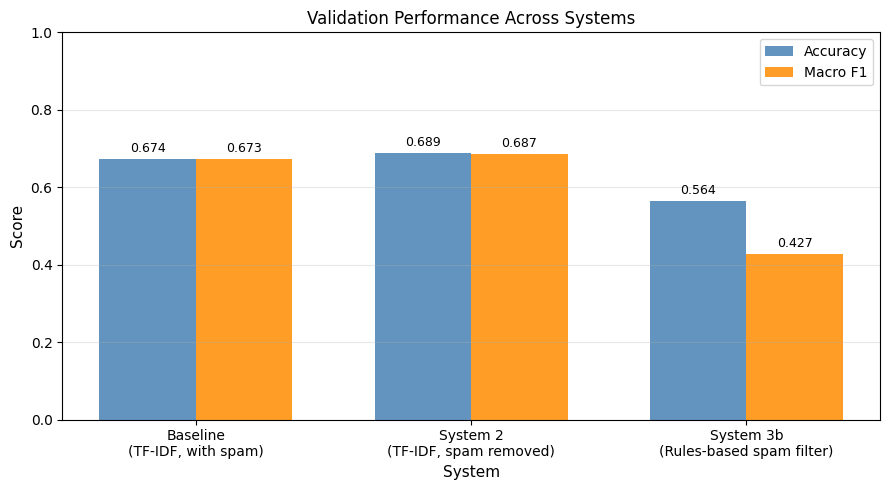

In [ ]:
# RESULTS COMPARISON — All Systems on Validation Set
# =============================================================================

# Create a version of final predictions where spam (-1) is mapped to 2
# (so it doesn't interfere with accuracy/F1 calculation on the full set)
val_preds_final_full = np.where(val_preds_final == -1, 2, val_preds_final)

# Dictionary of all systems for easy comparison
systems = {
    'Baseline\n(TF-IDF, with spam)': val_preds,                    # System 1
    'System 2\n(TF-IDF, spam removed)': val_preds_clean,           # System 2 (Clean-only)
    'System 3b\n(Rules-based spam filter)': val_preds_final_full   # Final submitted system
}

# Print comparison table
print(f"{'System':<35} {'Accuracy':>10} {'Macro F1':>10}")
print("-" * 57)

for name, preds in systems.items():
    acc = accuracy_score(y_val, preds)
    f1 = f1_score(y_val, preds, average='macro')
    # Replace newline with space for clean table printing
    clean_name = name.replace(chr(10), ' ')
    print(f"{clean_name:<35} {acc:>10.4f} {f1:>10.4f}")


# =============================================================================
# Visualisation: Bar Chart Comparison
# =============================================================================
fig, ax = plt.subplots(figsize=(9, 5))

labels = list(systems.keys())
accs = [accuracy_score(y_val, p) for p in systems.values()]
f1s = [f1_score(y_val, p, average='macro') for p in systems.values()]

x = np.arange(len(labels))
w = 0.35

# Plot bars
bars1 = ax.bar(x - w/2, accs, w, label='Accuracy', color='steelblue', alpha=0.85)
bars2 = ax.bar(x + w/2, f1s, w, label='Macro F1', color='darkorange', alpha=0.85)

# Add value labels on top of bars
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)

for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)

# Chart formatting
ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=10)
ax.set_ylim(0.0, 1.0)
ax.set_ylabel('Score', fontsize=11)
ax.set_xlabel('System', fontsize=11)
ax.set_title('Validation Performance Across Systems', fontsize=12)
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=200, bbox_inches='tight')
plt.show()

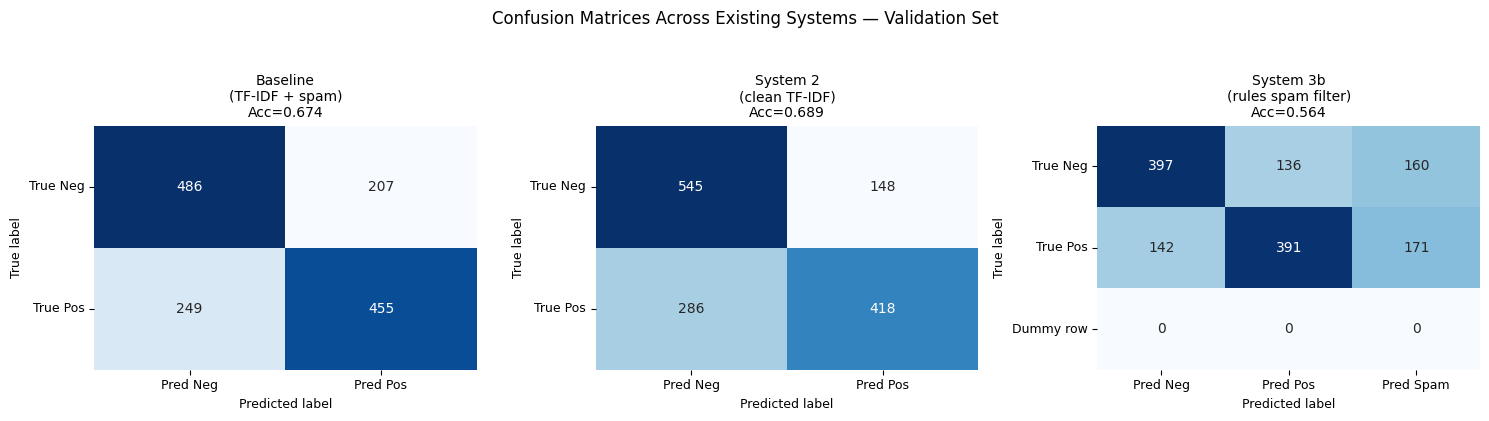

In [ ]:
# CONFUSION MATRIX COMPARISON — Existing Systems on Validation Set
# =============================================================================

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Systems to compare: (predictions, subplot title)
systems_cm = [
    (val_preds, 'Baseline\n(TF-IDF + spam)'),
    (val_preds_clean, 'System 2\n(clean TF-IDF)'),
    (val_preds_final_full, 'System 3b\n(rules spam filter)')
]

for ax, (preds, title) in zip(axes, systems_cm):

    # Generate confusion matrix (handles 2-class and 3-class with spam)
    cm = confusion_matrix(y_val, preds,
                          labels=[0, 1, 2] if 2 in np.unique(preds) else [0, 1])

    if cm.shape == (3, 3):
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                    xticklabels=['Pred Neg', 'Pred Pos', 'Pred Spam'],
                    yticklabels=['True Neg', 'True Pos', 'Dummy row'],
                    cbar=False)
    else:
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                    xticklabels=['Pred Neg', 'Pred Pos'],
                    yticklabels=['True Neg', 'True Pos'],
                    cbar=False)

    # Add accuracy to title
    acc = accuracy_score(y_val, preds)
    ax.set_title(f'{title}\nAcc={acc:.3f}', fontsize=10)

    ax.set_ylabel('True label', fontsize=9)
    ax.set_xlabel('Predicted label', fontsize=9)

    # Improve tick label readability
    ax.tick_params(axis='x', labelrotation=0, labelsize=9)
    ax.tick_params(axis='y', labelrotation=0, labelsize=9)

# Overall figure formatting
plt.suptitle('Confusion Matrices Across Existing Systems — Validation Set',
             fontsize=12, y=1.04)
plt.tight_layout()
plt.savefig('confusion_matrix_comparison.png', dpi=200, bbox_inches='tight')
plt.show()

## NLTK External Evaluation

As an additional experiment, the final sentiment model was tested on the NLTK `movie_reviews` dataset. This was done to check whether the system generalises to a separate set of real movie reviews rather than only performing well on the provided assignment data.

The same text preprocessing and trained classifier were reused, and the results were assessed using accuracy, macro F1-score, and a confusion matrix. These external results can then be compared with the validation-set results to judge how robust the model is under dataset shift.

In [ ]:
# EXTERNAL EVALUATION - NLTK movie_reviews (Using System 2)
# =============================================================================
import nltk
from nltk.corpus import movie_reviews
import pandas as pd
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

# Download if necessary
nltk.download('movie_reviews', quiet=True)

# Load clean NLTK movie_reviews dataset
documents = [movie_reviews.raw(fileid) for fileid in movie_reviews.fileids()]
labels = [1 if movie_reviews.categories(fileid)[0] == 'pos' else 0
          for fileid in movie_reviews.fileids()]

nltk_df = pd.DataFrame({'text': documents, 'label': labels})
print(f"NLTK movie_reviews dataset loaded: {len(nltk_df)} samples")
print(nltk_df['label'].value_counts())

# Apply the same preprocessing used in the main pipeline
nltk_df['clean_text'] = nltk_df['text'].apply(preprocess_text)

# Use System 2 (clean-only model) for fair generalisation test
X_nltk = vectorizer_clean.transform(nltk_df['clean_text'])
nltk_preds = model_clean.predict(X_nltk)

# Results
acc = accuracy_score(nltk_df['label'], nltk_preds)
macro_f1 = f1_score(nltk_df['label'], nltk_preds, average='macro')
cm = confusion_matrix(nltk_df['label'], nltk_preds)

print("\n" + "="*80)
print("EXTERNAL EVALUATION ON NLTK movie_reviews (System 2 - Clean-only)")
print("="*80)
print(f"Accuracy  : {acc:.4f}")
print(f"Macro F1  : {macro_f1:.4f}")
print("\nConfusion Matrix:")
print(cm)
print("\nClassification Report:")
print(classification_report(nltk_df['label'], nltk_preds))

NLTK movie_reviews dataset loaded: 2000 samples
label
0    1000
1    1000
Name: count, dtype: int64

EXTERNAL EVALUATION ON NLTK movie_reviews (System 2 - Clean-only)
Accuracy  : 0.7825
Macro F1  : 0.7773

Confusion Matrix:
[[935  65]
 [370 630]]

Classification Report:
              precision    recall  f1-score   support

           0       0.72      0.94      0.81      1000
           1       0.91      0.63      0.74      1000

    accuracy                           0.78      2000
   macro avg       0.81      0.78      0.78      2000
weighted avg       0.81      0.78      0.78      2000



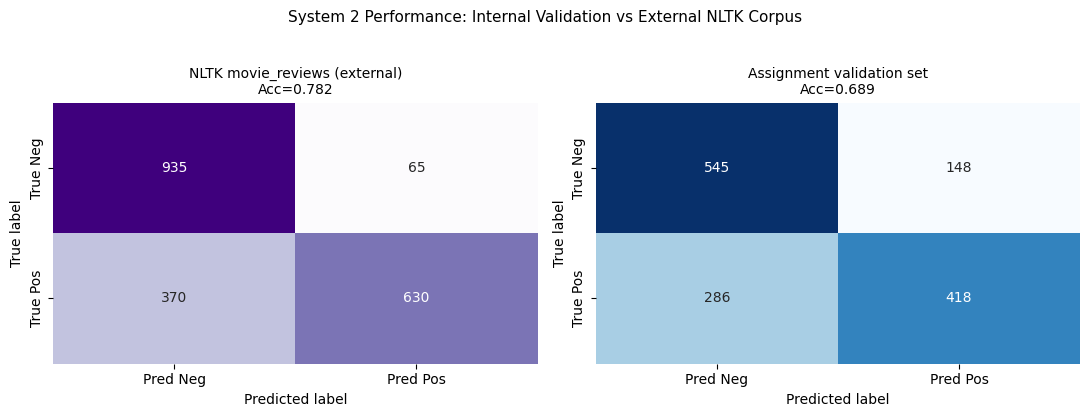


Generalisation Gap: 0.7825 (NLTK external) vs 0.6893 (Assignment validation)


In [ ]:
# NLTK CONFUSION MATRIX — External Evaluation Visualisation
# =============================================================================

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Confusion Matrix for NLTK external dataset (System 2)
cm_nltk = confusion_matrix(nltk_df['label'], nltk_preds)
sns.heatmap(cm_nltk, annot=True, fmt='d', cmap='Purples',
            ax=axes[0],
            xticklabels=['Pred Neg', 'Pred Pos'],
            yticklabels=['True Neg', 'True Pos'],
            cbar=False)

axes[0].set_title(
    f"NLTK movie_reviews (external)\nAcc={accuracy_score(nltk_df['label'], nltk_preds):.3f}",
    fontsize=10
)
axes[0].set_ylabel('True label')
axes[0].set_xlabel('Predicted label')

# Confusion Matrix for Assignment Validation Set (System 2)
cm_val = confusion_matrix(y_val, val_preds_clean)
sns.heatmap(cm_val, annot=True, fmt='d', cmap='Blues',
            ax=axes[1],
            xticklabels=['Pred Neg', 'Pred Pos'],
            yticklabels=['True Neg', 'True Pos'],
            cbar=False)

axes[1].set_title(
    f'Assignment validation set\nAcc={accuracy_score(y_val, val_preds_clean):.3f}',
    fontsize=10
)
axes[1].set_ylabel('True label')
axes[1].set_xlabel('Predicted label')

# Overall figure title and layout
plt.suptitle('System 2 Performance: Internal Validation vs External NLTK Corpus',
             fontsize=11, y=1.03)
plt.tight_layout()
plt.savefig('confusion_matrix_nltk.png', dpi=200, bbox_inches='tight')
plt.show()

# Print generalisation gap for quick reference
print(
    f"\nGeneralisation Gap: "
    f"{accuracy_score(nltk_df['label'], nltk_preds):.4f} (NLTK external) vs "
    f"{accuracy_score(y_val, val_preds_clean):.4f} (Assignment validation)"
)

In [ ]:
def save_as_csv(pred_labels, location = '.'):
    """
    Save the labels out as a .csv file
    :pred_labels: numpy array of shape (no_test_labels,) to be saved
    :param location: Directory to save results.csv in. Default to current working directory
    """
    assert pred_labels.shape[0]==1434, 'wrong number of labels, should be 1434 test labels'
    np.savetxt(location + '/results_task1.csv', pred_labels, delimiter=',')


In [ ]:
# FINAL SUBMISSION EXPORT — using worksheet helper function

submission_array = final_test_preds.reshape(-1)

print("Submission shape:", submission_array.shape)
print("Prediction counts:")
print(pd.Series(submission_array).value_counts().sort_index())

save_as_csv(submission_array, '.')
print("\nSaved as results_task1.csv")

check = pd.read_csv('results_task1.csv', header=None)
print("\nVerification:")
print(check.shape)
print(check[0].value_counts().sort_index())

Submission shape: (1434,)
Prediction counts:
-1    368
 0    529
 1    537
Name: count, dtype: int64

Saved as results_task1.csv

Verification:
(1434, 1)
0
-1.0    368
 0.0    529
 1.0    537
Name: count, dtype: int64


In [ ]:
from google.colab import files

# Download Task 1 predictions
files.download('results_task1.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>